In [1]:
from utils.binaries import *
from utils.plotting import *

23:21:26 (  +422ms) [INFO   ] -- import logging
23:21:26 (   +85ms) [INFO   ] -- import numpy as np
23:21:26 (   +10ms) [INFO   ] -- import uncertainties
23:21:27 (  +224ms) [INFO   ] -- import pandas as pd
23:21:27 (    +0ms) [WARNING] -- pandas support to be dropped at some point!
23:21:27 (    +1ms) [INFO   ] -- import binaries.tools as tools
23:21:27 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
23:21:27 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
23:21:27 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
23:21:27 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
23:21:27 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
23:21:27 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
23:21:27 (  +284ms) [INFO   ] -- import matplotlib.pyplot as plt
23:21:27 (  +382ms) [INFO   ] -- import seabor

In [35]:
olo_x, olo_y = np.loadtxt("olomouc.csv", delimiter=',', unpack=True)

In [38]:
from scipy.optimize import curve_fit

def inverse_view_factor(z, offset, r=0, R=0):

    z = z - offset
    a, b = R/z, r/z
    x = 1 + np.pow(a, -2) + np.pow(b/a, 2)
    y = np.sqrt(np.pow(x, 2) - 4 * np.pow(b/a, 2))

    return 0.5 * (x - y)

popt_olo, pcov_olo = curve_fit(inverse_view_factor, olo_x, olo_y * 1e9)

00:32:16 (  +11.3s) [DEBUG  ] -- font size set to 9.5
00:32:16 (    +1ms) [DEBUG  ] -- label size set to 13.0
00:32:16 (    +0ms) [DEBUG  ] -- figure size set to [6.6, 2.2]
00:32:16 (    +0ms) [DEBUG  ] -- markersize set to 2.0
00:32:16 (    +1ms) [DEBUG  ] -- usetex set to False


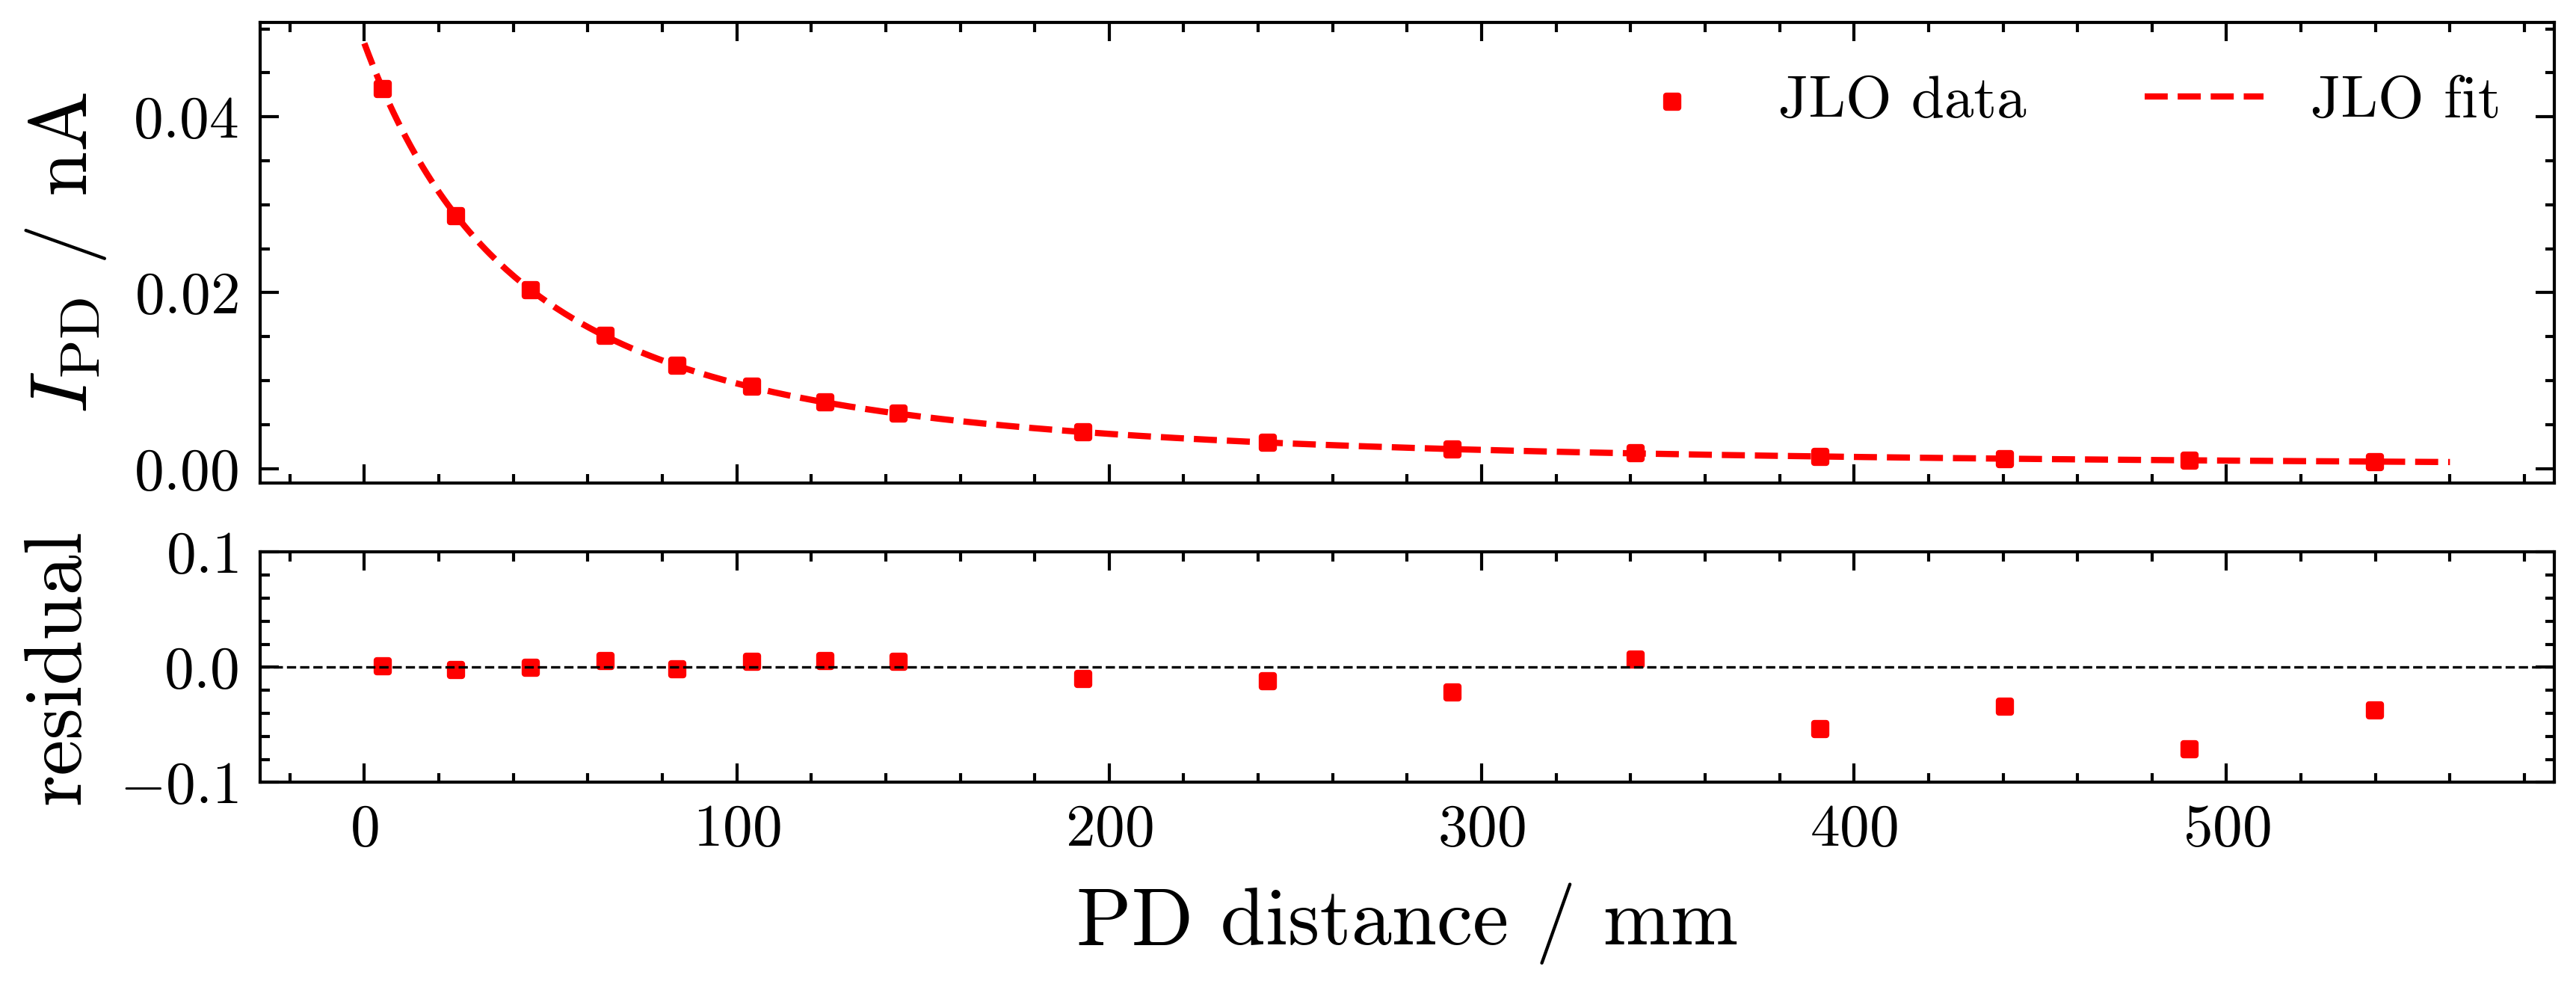

In [65]:
set_plt_style("slim")

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[1, 0.5], sharex=True)

X = np.linspace(0, 560, 500)

ax1.scatter(olo_x, olo_y * 1e9, label="JLO data", marker='s', c='r')
ax1.plot(X, inverse_view_factor(X, *popt_olo), marker='none', label="JLO fit", c='r', ls='--')
ax1.set_ylabel(r"$I_\mathrm{PD}$ / nA")
ax2.set_ylabel(r"residual")
ax2.set_xlabel(r"PD distance / mm")
ax1.legend(ncol=2)

ax2.scatter(olo_x, (olo_y * 1e9 - inverse_view_factor(olo_x, *popt_olo))/inverse_view_factor(olo_x, *popt_olo), marker='s', c='r')

ax2.set_ylim(-0.1, 0.1)
ax2.axhline(0, c='k', ls='--', lw=0.4)
# plt.yscale("log")

In [21]:
for i in range(len(olo_x)):
    print(f"({olo_x[i]:.2f}, {olo_y[i]*1e9:.5f})")

(4.92, 0.04320)
(24.58, 0.02873)
(44.68, 0.02030)
(64.79, 0.01512)
(84.00, 0.01166)
(104.11, 0.00929)
(123.77, 0.00756)
(143.43, 0.00626)
(193.03, 0.00410)
(242.63, 0.00292)
(292.23, 0.00216)
(341.38, 0.00173)
(390.97, 0.00130)
(440.57, 0.00108)
(490.17, 0.00086)
(539.77, 0.00076)
